# Weekly Project 2!

## Introduction to Road Traffic Accidents (RTA) Dataset

### Dataset Overview
The RTA Dataset provides a detailed snapshot of road traffic accidents, capturing a range of data from accident conditions to casualty details. This dataset is essential for analyzing patterns and causes of accidents to improve road safety.

### Data Characteristics
- **Entries**: The dataset contains 12,316 entries.
- **Features**: There are 32 features in the dataset, which include:
  - `Time`: Time when the accident occurred.
  - `Day_of_week`: Day of the week.
  - `Age_band_of_driver`: Age group of the driver involved.
  - `Sex_of_driver`: Gender of the driver.
  - `Educational_level`: Educational level of the driver.
  - `Type_of_vehicle`: Type of vehicle involved in the accident.
  - `Cause_of_accident`: Reported cause of the accident.
  - `Accident_severity`: Severity of the accident.
- **Target Column**: `Accident_severity` is used as the target column for modeling. This feature classifies the severity of each accident.

### Objective
Students will use this dataset to apply various data visualization, modeling, and evaluation techniques learned in class. The primary goal is to build models that can accurately predict the severity of accidents and to identify the key factors that contribute to severe accidents.

## Import Libraries
Import all the necessary libraries here. Include libraries for handling data (like pandas), visualization (like matplotlib and seaborn), and modeling (like scikit-learn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
import plotly.express as px


## Load Data
Load the dataset from the provided CSV file into a DataFrame.

In [2]:
df = pd.read_csv('/content/RTA_Dataset.csv')

In [3]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


  ## Exploratory Data Analysis (EDA)
Perform EDA to understand the data better. This involves several steps to summarize the main characteristics, uncover patterns, and establish relationships:
* Find the dataset information and observe the datatypes.
* Check the shape of the data to understand its structure.
* View the the data with various functions to get an initial sense of the data.
* Perform summary statistics on the dataset to grasp central tendencies and variability.
* Check for duplicated data.
* Check for null values.

And apply more if needed!


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [5]:
df.shape

(12316, 32)

In [6]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [9]:
fig = px.histogram(df, x="Number_of_vehicles_involved")
fig.show()


fig = px.histogram(df, x="Number_of_casualties")
fig.show()

In [10]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Educational_level,741
Vehicle_driver_relation,579
Driving_experience,829
Type_of_vehicle,950
Owner_of_vehicle,482
Service_year_of_vehicle,3928


In [11]:
# those columns conttains null values there exsit not necessary
column_to_drop = [
                  'Educational_level',
                 'Vehicle_driver_relation',
                 'Owner_of_vehicle',
                  'Work_of_casuality',
                  'Fitness_of_casuality',
                  ]

df = df.drop(column_to_drop, axis=1)

In [12]:

# dropping unnecessray columns
column_to_drop = [
                  'Casualty_class',
                  'Sex_of_casualty',
                  'Age_band_of_casualty',
                  'Casualty_severity',
                  'Pedestrian_movement',
                  ]

df = df.drop(column_to_drop, axis=1)

In [13]:

df['Type_of_vehicle'] = df['Type_of_vehicle'].str.replace(r'Lorry.*', 'Lorry', regex=True)
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.replace(r'lorry.*', 'Lorry', regex=True)
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.replace(r'Public.*', 'Public', regex=True)
df['Driving_experience'] = df['Driving_experience'].replace('unknown', 'Unknown')

In [14]:
df['Type_of_vehicle'].unique()

array(['Automobile', 'Public', 'Lorry', nan, 'Long Lorry', 'Taxi',
       'Pick up upto 10Q', 'Stationwagen', 'Ridden horse', 'Other',
       'Bajaj', 'Turbo', 'Motorcycle', 'Special vehicle', 'Bicycle'],
      dtype=object)

In [15]:
df['Time'] = pd.to_datetime(df['Time'])

/tmp/ipykernel_8218/2145562215.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



## Data Preprocessing
Data preprocessing is essential for transforming raw data into a format suitable for further analysis and modeling. Follow these steps to ensure your data is ready for predictive modeling or advanced analytics:
- **Handling Missing Values**: Replace missing values with appropriate statistics (mean, median, mode) or use more complex imputation techniques.
- **Normalization/Scaling**: Scale data to a small, specified range like 0 to 1, or transform it to have a mean of zero and a standard deviation of one.
- **Label Encoding**: Convert categorical text data into model-understandable numbers where the labels are ordered.
- **One-Hot Encoding**: Use for nominal categorical data where no ordinal relationship exists to transform the data into a binary column for each category. (Be careful not to increase the dimensionality significantly)
- **Detection and Treatment of Outliers**: Use statistical tests, box plots, or scatter plots to identify outliers and then cap, trim, or use robust methods to reduce the effect of outliers, depending on the context.
- **Feature Engineering**: Enhance your dataset by creating new features and transforming existing ones. This might involve combining data from different columns, applying transformations, or reducing dimensionality with techniques like PCA to improve model performance.

Consider these steps as a foundation, and feel free to introduce additional preprocessing techniques as needed to address specific characteristics of your dataset.

In [16]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Driving_experience,829
Type_of_vehicle,950
Service_year_of_vehicle,3928
Defect_of_vehicle,4427
Area_accident_occured,239
Lanes_or_Medians,385


In [17]:
df['Driving_experience'].fillna('Unknown' , inplace=True)

df['Type_of_vehicle'].fillna(df['Type_of_vehicle'].mode()[0] , inplace=True)

df.drop('Service_year_of_vehicle' , axis=1 , inplace=True) # a lot of 'unknown' and missing values , so i will drop the column

df.drop('Defect_of_vehicle' , axis=1 , inplace=True) # a lot of null values , most of it (no defect) , drop the column

df = df.dropna(subset=['Area_accident_occured'])

df['Lanes_or_Medians'].fillna('Unknown' , inplace=True)

df = df.dropna(subset=['Road_allignment'])

df['Types_of_Junction'].fillna('Unknown' , inplace=True)

df = df.dropna(subset=['Type_of_collision'])

df['Vehicle_movement'].fillna('Unknown' , inplace=True)

df['Road_surface_type'].fillna(df['Road_surface_type'].mode()[0]  , inplace=True)

/tmp/ipykernel_8218/1024020063.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_8218/1024020063.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

In [18]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_band_of_driver,0
Sex_of_driver,0
Driving_experience,0
Type_of_vehicle,0
Area_accident_occured,0
Lanes_or_Medians,0
Road_allignment,0
Types_of_Junction,0


In [19]:
df['Accident_severity'].value_counts()

,count
Accident_severity,
Slight Injury,9992
Serious Injury,1660
Fatal injury,151


In [20]:
acc_sev = df['Accident_severity'].value_counts()

fig = px.bar(acc_sev, x=acc_sev.index, y='count', title='Total count of each accident severity', color_discrete_sequence=['#DD5050'])

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=acc_sev.index,
        ticktext=acc_sev.index
    )
)
fig.show()

In [22]:
# take sample from Slight Injury class
df_slight = df[df['Accident_severity'] == 'Slight Injury']
df_slight = df_slight.sample(2000)

df_Serious = df[df['Accident_severity'] == 'Serious Injury']

# Duplicate the dataframe 8 times
df_Fatal = df[df['Accident_severity'] == 'Fatal injury']
df_Fatal = pd.concat([df_Fatal] * 8, ignore_index=True)

print(len(df_Fatal))
df = pd.concat([df_slight, df_Serious, df_Fatal])

1208


In [23]:
acc_sev = df['Accident_severity'].value_counts()

fig = px.bar(acc_sev, x=acc_sev.index, y='count', title='Total count of each accident severity', color_discrete_sequence=['#DD5050'])

fig.update_layout(
    xaxis=dict(
        tickmode='array',
        tickvals=acc_sev.index,
        ticktext=acc_sev.index
    )
)
fig.show()

In [24]:
df.shape

(4868, 20)

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop("Accident_severity", axis=1) # drop labels for training set
y = df["Accident_severity"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [26]:
X_train.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident
8800,2026-03-28 17:05:00,Thursday,31-50,Male,2-5yr,Motorcycle,Residential areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,Changing lane to the right
801,2026-03-28 22:48:00,Monday,31-50,Male,Above 10yr,Public,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Wet or damp,Darkness - lights lit,Raining,Vehicle with vehicle collision,2,1,Moving Backward,Driving carelessly
1112,2026-03-28 11:16:00,Sunday,18-30,Male,Below 1yr,Other,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,5,Moving Backward,Changing lane to the left
5072,2026-03-28 03:26:00,Thursday,Unknown,Female,1-2yr,Lorry,Other,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,Moving Backward
1654,2026-03-28 23:53:00,Wednesday,31-50,Male,Below 1yr,Automobile,Other,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,1,1,Moving Backward,Driving under the influence of drugs


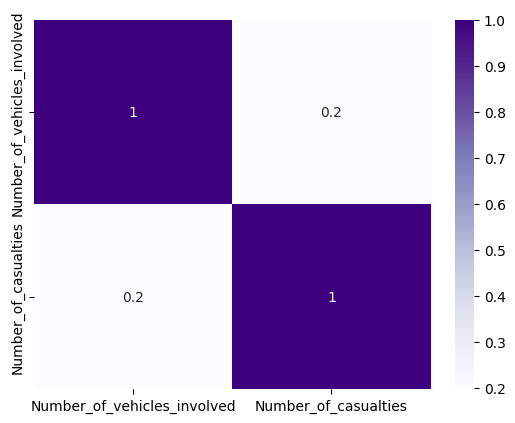

In [27]:

# only tow numerical columns
corr_matrix= df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='Purples', annot=True )

plt.show()

In [30]:
# Age_band_of_driver
grouped_df = df.groupby(['Accident_severity', 'Age_band_of_driver']).size().reset_index(name='count')
grouped_df

color_palette = {'Slight': 'lightblue', 'Serious': 'orange', 'Fatal': 'red'}

fig = px.bar(grouped_df, x='Age_band_of_driver', y='count', color='Accident_severity', color_discrete_map=color_palette, barmode='group', title='Accident Severity by Age')

fig.update_layout(
    xaxis_title='Collision Type',
    yaxis_title='Accident Count'
)

fig.show()

## Feature Selection
- Choose features that you believe will most influence the outcome based on your analysis and the insights from your visualizations. Focus on those that appear most impactful to include in your modeling.

## Train-Test Split
* Divide the dataset into training and testing sets to evaluate the performance of your models.

In [32]:

grouped_df2 = df.groupby(['Accident_severity', 'Road_surface_type']).size().reset_index(name='count')


color_palette = {'Slight': 'lightblue', 'Serious': 'orange', 'Fatal': 'red'}

fig = px.bar(grouped_df2, x='Road_surface_type', y='count', color='Accident_severity', barmode='group', color_discrete_map=color_palette, title='Accident Severity by Road surface type')

fig.update_layout(
    xaxis_title='Collision Type',
    yaxis_title='Accident Count'
)

fig.show()

In [33]:
grouped_df4 = df.groupby(['Accident_severity', 'Number_of_casualties']).size().reset_index(name='count')

color_palette = {'Slight': 'lightblue', 'Serious': 'orange', 'Fatal': 'red'}
fig = px.bar(grouped_df4, x='Number_of_casualties', y='count', color='Accident_severity',color_discrete_map=color_palette,  barmode='group', title='Accident Severity by Road surface type')

fig.update_layout(
    xaxis_title='Collision Type',
    yaxis_title='Accident Count'
)

fig.show()

In [34]:
X_train.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident
8800,2026-03-28 17:05:00,Thursday,31-50,Male,2-5yr,Motorcycle,Residential areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,Changing lane to the right
801,2026-03-28 22:48:00,Monday,31-50,Male,Above 10yr,Public,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,Y Shape,Asphalt roads,Wet or damp,Darkness - lights lit,Raining,Vehicle with vehicle collision,2,1,Moving Backward,Driving carelessly
1112,2026-03-28 11:16:00,Sunday,18-30,Male,Below 1yr,Other,Other,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,5,Moving Backward,Changing lane to the left
5072,2026-03-28 03:26:00,Thursday,Unknown,Female,1-2yr,Lorry,Other,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,1,Other,Moving Backward
1654,2026-03-28 23:53:00,Wednesday,31-50,Male,Below 1yr,Automobile,Other,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,1,1,Moving Backward,Driving under the influence of drugs


In [35]:

column_to_drop = [
                  'Time',
                  'Day_of_week',
                  'Lanes_or_Medians',
                  'Road_allignment',
                  'Types_of_Junction',
                  'Number_of_casualties',
                  'Road_surface_type',
                  'Vehicle_movement',
                  'Area_accident_occured',
                  ]

X_train = X_train.drop(column_to_drop, axis=1)
X_test = X_test.drop(column_to_drop, axis=1)

In [36]:
X_train.head()

,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Cause_of_accident
8800,31-50,Male,2-5yr,Motorcycle,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Changing lane to the right
801,31-50,Male,Above 10yr,Public,Wet or damp,Darkness - lights lit,Raining,Vehicle with vehicle collision,2,Driving carelessly
1112,18-30,Male,Below 1yr,Other,Dry,Daylight,Normal,Collision with roadside objects,2,Changing lane to the left
5072,Unknown,Female,1-2yr,Lorry,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Moving Backward
1654,31-50,Male,Below 1yr,Automobile,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,1,Driving under the influence of drugs


In [37]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

num_pip = make_pipeline(MinMaxScaler())
cat_pip_one_hot = make_pipeline(OneHotEncoder(handle_unknown='ignore'))
cat_pip_ordinal = make_pipeline(OrdinalEncoder(categories=[['Unknown', 'No Licence', 'Below 1yr' , '1-2yr' , '2-5yr' , '5-10yr' , 'Above 10yr'],
                                                           ['Unknown' , 'Under 18' , '18-30' , '31-50' , 'Over 51']]))

pre_pip = ColumnTransformer([
    ('cat_one_hot', cat_pip_one_hot, ['Type_of_vehicle',  'Sex_of_driver' , 'Road_surface_conditions', 'Light_conditions',
                                      'Weather_conditions', 'Type_of_collision', 'Cause_of_accident']),
    ('cat_ordinal', cat_pip_ordinal, ['Driving_experience',  'Age_band_of_driver']),
    ])

In [38]:
train_prepared = pre_pip.fit_transform(X_train)
X_test_prepared = pre_pip.transform(X_test)

In [44]:
X_train_prepared

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
...,...
3889,<Compressed Sparse Row sparse matrix of dtype ...
3890,<Compressed Sparse Row sparse matrix of dtype ...
3891,<Compressed Sparse Row sparse matrix of dtype ...
3892,<Compressed Sparse Row sparse matrix of dtype ...


In [51]:
type(X_train_prepared)

pandas.core.frame.DataFrame

In [56]:
X_train_prepared = pd.get_dummies(X_train)

In [57]:

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_prepared, y_train)

LogisticRegression(max_iter=1000)

In [58]:

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_prepared, y_train)

DecisionTreeClassifier()

In [59]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_prepared, y_train)

SVC()

In [60]:

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_prepared, y_train)

KNeighborsClassifier()

In [64]:
X_train_prepared, X_test_prepared = X_train_prepared.align(
    X_test_prepared,
    join='left',
    axis=1,
    fill_value=0
)

In [65]:
y_pred_log_reg = log_reg.predict(X_test_prepared)

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

acc = accuracy_score(y_test, y_pred_log_reg)

print(acc)

0.41786447638603696


In [67]:
# 1
X_train_prepared = pd.get_dummies(X_train)


In [68]:

# 2
X_test_prepared = pd.get_dummies(X_test)



In [69]:
# 3 (مهم جدًا)
X_train_prepared, X_test_prepared = X_train_prepared.align(
    X_test_prepared, join='left', axis=1, fill_value=0
)


In [70]:

# 4
log_reg.fit(X_train_prepared, y_train)


LogisticRegression(max_iter=1000)

In [71]:

# 5
y_pred = log_reg.predict(X_test_prepared)

In [72]:

from sklearn.metrics import confusion_matrix, accuracy_score

# LogisticRegression
y_pred_log_reg = log_reg.predict(X_test_prepared)
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
acc = accuracy_score(y_test, y_pred_log_reg)
acc

0.47433264887063653

In [73]:
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
cm_log_reg

array([[ 97,  67,  96],
       [ 45, 102, 160],
       [ 66,  78, 263]])

In [74]:
y_pred_dt = dt.predict(X_test_prepared)
acc = accuracy_score(y_test, y_pred_dt)
acc

0.6396303901437371

In [75]:
y_pred_svm = svm.predict(X_test_prepared)
acc = accuracy_score(y_test, y_pred_svm)
acc

0.5780287474332649

In [76]:

y_pred_knn = knn.predict(X_test_prepared)
acc = accuracy_score(y_test, y_pred_knn)
acc


0.5862422997946611